# Task 6 — Training Analysis & Optimization
**COVID-19 Radiography Dataset | CNN vs FFNN**

Covers:
- Learning curves (loss & accuracy over epochs)
- Overfitting / underfitting diagnosis
- Training & inference time comparison
- Regularization effects study

In [1]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow import keras

print(f"PyTorch  : {torch.__version__}")
print(f"TensorFlow: {tf.__version__}")
print(f"Device   : {'CUDA' if torch.cuda.is_available() else 'CPU'}")

PyTorch  : 2.11.0+cpu
TensorFlow: 2.21.0
Device   : CPU


## 1 — Data Preparation
Same preprocessing pipeline as the other notebooks so everything is consistent.

In [2]:
DATA_DIR   = "./COVID-19_Radiography_Dataset"
BATCH_SIZE = 32
DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Augmented transforms for training only
train_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((128, 128)),
    transforms.RandomRotation(10),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

# No augmentation on val/test — we want clean evaluation
test_transforms = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

full_train = datasets.ImageFolder(root=DATA_DIR, transform=train_transforms)
full_test  = datasets.ImageFolder(root=DATA_DIR, transform=test_transforms)

CLASS_NAMES  = list(full_train.class_to_idx.keys())
NUM_CLASSES  = len(CLASS_NAMES)

targets = full_train.targets
indices = list(range(len(full_train)))

train_idx, temp_idx, train_tgt, temp_tgt = train_test_split(
    indices, targets, test_size=0.40, stratify=targets, random_state=42
)
val_idx, test_idx, _, _ = train_test_split(
    temp_idx, temp_tgt, test_size=0.50, stratify=temp_tgt, random_state=42
)

train_loader = DataLoader(Subset(full_train, train_idx), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(Subset(full_test,  val_idx),   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(Subset(full_test,  test_idx),  batch_size=BATCH_SIZE, shuffle=False)

print(f"Classes : {CLASS_NAMES}")
print(f"Train: {len(train_idx)} | Val: {len(val_idx)} | Test: {len(test_idx)}")

Classes : ['COVID', 'Lung_Opacity', 'Normal', 'Viral Pneumonia']
Train: 25329 | Val: 8443 | Test: 8444


## 2 — Model Definitions
Both models are defined here so the training loops below can track history properly.

In [3]:
# ── FFNN (PyTorch) — same architecture as FFNN4.ipynb ───────────────────────
class FFNN_COVID(nn.Module):
    def __init__(self, num_classes=4, use_dropout=True, use_batchnorm=True):
        super(FFNN_COVID, self).__init__()

        # Convolutional feature extractor
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.pool  = nn.MaxPool2d(2, 2)
        self.relu  = nn.ReLU(inplace=True)

        # Spatial dropout between conv blocks
        self.dropout2d = nn.Dropout2d(0.25) if use_dropout else nn.Identity()

        self.flatten = nn.Flatten()

        # Fully-connected head
        self.fc1 = nn.Linear(8192, 512)
        self.fc2 = nn.Linear(512, 128)
        self.fc3 = nn.Linear(128, num_classes)

        # BatchNorm layers — toggled for regularization study
        self.bn1 = nn.BatchNorm1d(512) if use_batchnorm else nn.Identity()
        self.bn2 = nn.BatchNorm1d(128) if use_batchnorm else nn.Identity()

        # Regular dropout in FC layers
        self.dropout = nn.Dropout(0.5) if use_dropout else nn.Identity()

    def forward(self, x):
        x = self.relu(self.conv1(x)); x = self.pool(x); x = self.dropout2d(x)
        x = self.relu(self.conv2(x)); x = self.pool(x); x = self.dropout2d(x)
        x = self.relu(self.conv3(x))
        x = F.adaptive_avg_pool2d(x, (8, 8))
        x = self.flatten(x)
        x = self.dropout(self.relu(self.bn1(self.fc1(x))))
        x = self.dropout(self.relu(self.bn2(self.fc2(x))))
        return self.fc3(x)


# ── CNN (Keras/TF) — must match the CNN.ipynb architecture ──────────────────
def build_cnn(num_classes=4):
    model = keras.Sequential([
        keras.layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(128,128,1)),
        keras.layers.MaxPooling2D(2,2),
        keras.layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        keras.layers.MaxPooling2D(2,2),
        keras.layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        keras.layers.GlobalAveragePooling2D(),
        keras.layers.Dense(256, activation='relu'),
        keras.layers.Dropout(0.5),
        keras.layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

print("Model classes defined.")

Model classes defined.


## 3 — Training Loop with History Tracking (FFNN)
We retrain the FFNN for the same number of epochs but now record train **and** validation loss/accuracy each epoch.

In [4]:
def train_ffnn_with_history(model, train_loader, val_loader, epochs=10, lr=1e-3):
    """
    Trains the FFNN and returns a history dict with
    train/val loss and accuracy per epoch.
    Also records total training time.
    """
    model = model.to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = {'train_loss': [], 'val_loss': [],
               'train_acc': [],  'val_acc': []}

    total_start = time.time()

    for epoch in range(epochs):

        # ── Training phase ──────────────────────────────────────────────────
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total   += labels.size(0)

        train_loss = running_loss / len(train_loader)
        train_acc  = correct / total

        # ── Validation phase ─────────────────────────────────────────────────
        model.eval()
        val_loss_sum, val_correct, val_total = 0.0, 0, 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(DEVICE), labels.to(DEVICE)
                outputs = model(images)
                loss    = criterion(outputs, labels)
                val_loss_sum += loss.item()
                _, predicted  = torch.max(outputs, 1)
                val_correct  += (predicted == labels).sum().item()
                val_total    += labels.size(0)

        val_loss = val_loss_sum / len(val_loader)
        val_acc  = val_correct / val_total

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        print(f"Epoch [{epoch+1:02d}/{epochs}]  "
              f"Train Loss: {train_loss:.4f} Acc: {train_acc*100:.2f}%  |  "
              f"Val Loss: {val_loss:.4f} Acc: {val_acc*100:.2f}%")

    history['train_time_sec'] = time.time() - total_start
    print(f"\nTotal training time: {history['train_time_sec']:.1f}s")
    return model, history


# Train FFNN — 10 epochs so learning curves have enough points to analyse
EPOCHS = 10
ffnn_model = FFNN_COVID(num_classes=NUM_CLASSES)
ffnn_model, ffnn_history = train_ffnn_with_history(
    ffnn_model, train_loader, val_loader, epochs=EPOCHS
)

Epoch [01/10]  Train Loss: 1.0074 Acc: 56.65%  |  Val Loss: 0.8536 Acc: 63.39%
Epoch [02/10]  Train Loss: 0.8889 Acc: 62.53%  |  Val Loss: 0.7794 Acc: 67.29%
Epoch [03/10]  Train Loss: 0.8408 Acc: 65.19%  |  Val Loss: 0.7214 Acc: 70.70%
Epoch [04/10]  Train Loss: 0.8000 Acc: 67.12%  |  Val Loss: 0.7019 Acc: 71.29%
Epoch [05/10]  Train Loss: 0.7761 Acc: 68.21%  |  Val Loss: 0.6628 Acc: 72.98%
Epoch [06/10]  Train Loss: 0.7475 Acc: 69.44%  |  Val Loss: 0.6493 Acc: 74.01%
Epoch [07/10]  Train Loss: 0.7348 Acc: 69.98%  |  Val Loss: 0.6378 Acc: 73.97%
Epoch [08/10]  Train Loss: 0.7125 Acc: 70.91%  |  Val Loss: 0.6065 Acc: 75.77%
Epoch [09/10]  Train Loss: 0.6987 Acc: 71.78%  |  Val Loss: 0.5922 Acc: 76.19%
Epoch [10/10]  Train Loss: 0.6883 Acc: 72.11%  |  Val Loss: 0.5750 Acc: 76.88%

Total training time: 3179.4s


## 4 — Training Loop with History Tracking (CNN / Keras)
Keras `.fit()` returns a `History` object automatically — we just need to pass a validation set.

In [5]:
# Convert PyTorch val_loader to numpy arrays for Keras
def loader_to_numpy(loader):
    """Pull all batches from a torch DataLoader into numpy arrays."""
    imgs_list, lbls_list = [], []
    for imgs, lbls in loader:
        # Keras expects (N, H, W, C) — permute from (N, C, H, W)
        imgs_list.append(imgs.permute(0,2,3,1).numpy())
        lbls_list.append(lbls.numpy())
    return np.concatenate(imgs_list), np.concatenate(lbls_list)

print("Converting val set for Keras...")
X_val, y_val = loader_to_numpy(val_loader)

# We need a Keras-compatible training generator too
print("Converting train set for Keras (this takes a moment)...")
X_train, y_train = loader_to_numpy(train_loader)

print(f"X_train: {X_train.shape} | X_val: {X_val.shape}")

# Build and train CNN
cnn_model = build_cnn(NUM_CLASSES)

cnn_start = time.time()
cnn_keras_history = cnn_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)
cnn_train_time = time.time() - cnn_start
print(f"\nCNN total training time: {cnn_train_time:.1f}s")

Converting val set for Keras...
Converting train set for Keras (this takes a moment)...
X_train: (25329, 128, 128, 1) | X_val: (8443, 128, 128, 1)
Epoch 1/10
792/792 ━━━━━━━━━━━━━━━━━━━━ 110s 136ms/step - accuracy: 0.5029 - loss: 1.1601 - val_accuracy: 0.5073 - val_loss: 1.1561
Epoch 2/10
792/792 ━━━━━━━━━━━━━━━━━━━━ 105s 132ms/step - accuracy: 0.5776 - loss: 1.0101 - val_accuracy: 0.5935 - val_loss: 0.9747
Epoch 3/10
792/792 ━━━━━━━━━━━━━━━━━━━━ 107s 136ms/step - accuracy: 0.6126 - loss: 0.9269 - val_accuracy: 0.6077 - val_loss: 0.9036
Epoch 4/10
792/792 ━━━━━━━━━━━━━━━━━━━━ 105s 132ms/step - accuracy: 0.6323 - loss: 0.8820 - val_accuracy: 0.6075 - val_loss: 0.9253
Epoch 5/10
792/792 ━━━━━━━━━━━━━━━━━━━━ 105s 133ms/step - accuracy: 0.6579 - loss: 0.8348 - val_accuracy: 0.6654 - val_loss: 0.7970
Epoch 6/10
792/792 ━━━━━━━━━━━━━━━━━━━━ 105s 133ms/step - accuracy: 0.6787 - loss: 0.7934 - val_accuracy: 0.6996 - val_loss: 0.7401
Epoch 7/10
792/792 ━━━━━━━━━━━━━━━━━━━━ 110s 138ms/step - acc

## 5 — Learning Curves
Plot train vs validation loss and accuracy for both models side by side.

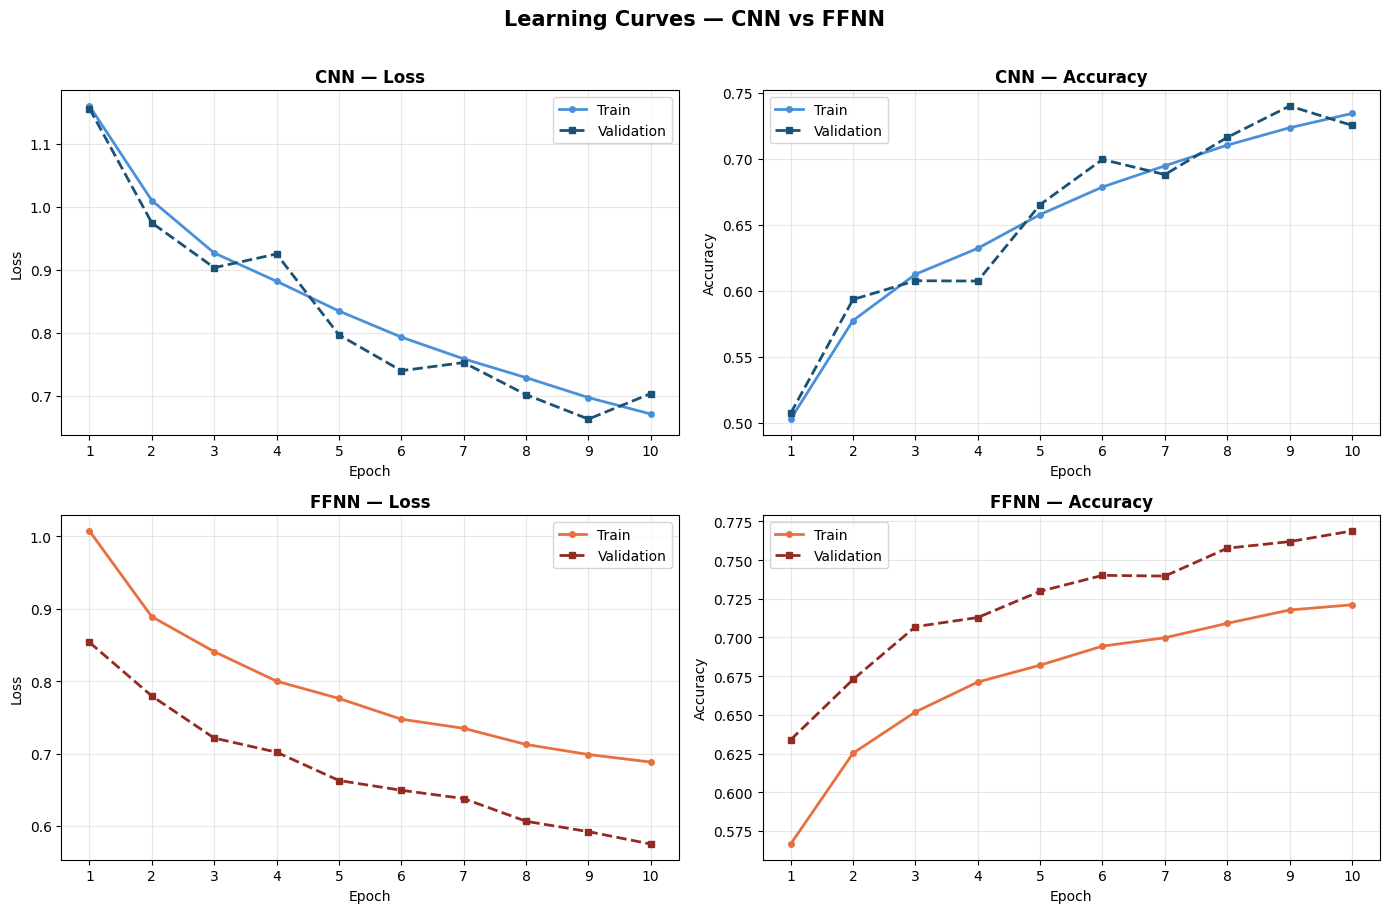

Saved: learning_curves.png


In [6]:
epochs_range = range(1, EPOCHS + 1)

# Pull CNN history from Keras object
cnn_history = {
    'train_loss': cnn_keras_history.history['loss'],
    'val_loss':   cnn_keras_history.history['val_loss'],
    'train_acc':  cnn_keras_history.history['accuracy'],
    'val_acc':    cnn_keras_history.history['val_accuracy'],
}

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Learning Curves — CNN vs FFNN', fontsize=15, fontweight='bold', y=1.01)

COLORS = {
    'train_cnn':  '#4A90D9',
    'val_cnn':    '#1A5276',
    'train_ffnn': '#E87040',
    'val_ffnn':   '#922B21',
}

def plot_curve(ax, train_vals, val_vals, title, ylabel, c_train, c_val):
    ax.plot(epochs_range, train_vals, color=c_train, lw=2,
            marker='o', markersize=4, label='Train')
    ax.plot(epochs_range, val_vals,   color=c_val,   lw=2,
            marker='s', markersize=4, linestyle='--', label='Validation')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.grid(alpha=0.3)
    ax.set_xticks(list(epochs_range))

plot_curve(axes[0,0], cnn_history['train_loss'],  cnn_history['val_loss'],
           'CNN — Loss',     'Loss',     COLORS['train_cnn'],  COLORS['val_cnn'])

plot_curve(axes[0,1], cnn_history['train_acc'],   cnn_history['val_acc'],
           'CNN — Accuracy', 'Accuracy', COLORS['train_cnn'],  COLORS['val_cnn'])

plot_curve(axes[1,0], ffnn_history['train_loss'], ffnn_history['val_loss'],
           'FFNN — Loss',     'Loss',     COLORS['train_ffnn'], COLORS['val_ffnn'])

plot_curve(axes[1,1], ffnn_history['train_acc'],  ffnn_history['val_acc'],
           'FFNN — Accuracy', 'Accuracy', COLORS['train_ffnn'], COLORS['val_ffnn'])

plt.tight_layout()
plt.savefig('learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: learning_curves.png")

## 6 — Overfitting / Underfitting Analysis
The gap between train and val curves is the main signal.
- **Overfitting**: train loss keeps dropping while val loss rises or stagnates
- **Underfitting**: both curves are high — the model hasn't learned enough
- **Good fit**: both curves converge and stay close

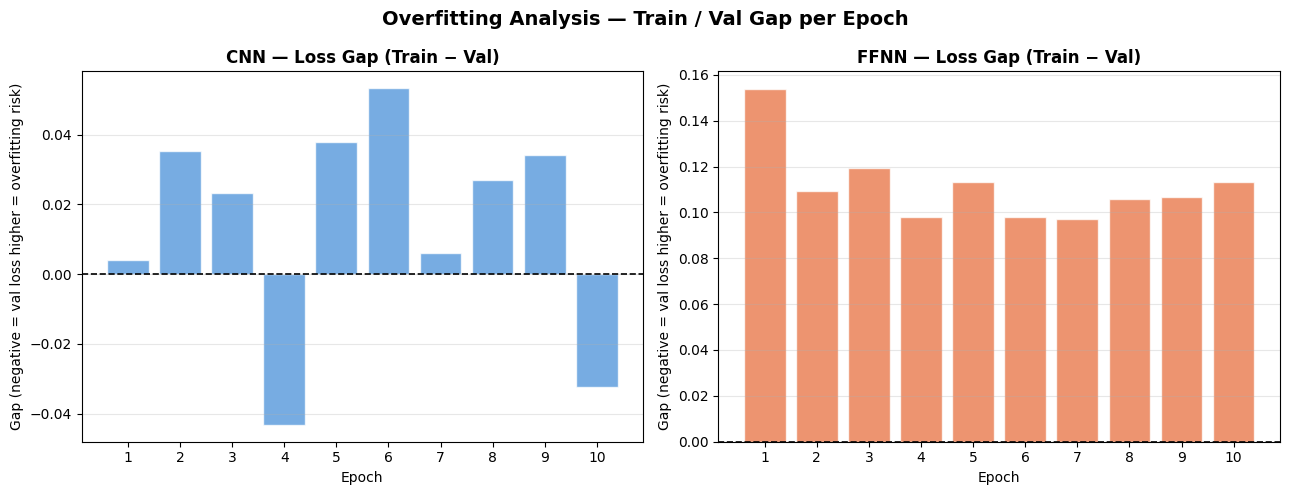


── Overfitting Diagnosis ──────────────────────────
CNN   | Final gap: -0.0324 | Gap trend: INCREASING | → Good generalisation
FFNN  | Final gap: +0.1133 | Gap trend: INCREASING | → Good generalisation


In [7]:
def overfitting_gap(history):
    """
    Computes the train-val gap per epoch.
    A growing positive gap = model is overfitting.
    """
    loss_gap = np.array(history['train_loss']) - np.array(history['val_loss'])
    acc_gap  = np.array(history['val_acc'])    - np.array(history['train_acc'])
    return loss_gap, acc_gap

cnn_loss_gap,  cnn_acc_gap  = overfitting_gap(cnn_history)
ffnn_loss_gap, ffnn_acc_gap = overfitting_gap(ffnn_history)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Overfitting Analysis — Train / Val Gap per Epoch',
             fontsize=14, fontweight='bold')

for ax, gap, label, color in [
    (axes[0], cnn_loss_gap,  'CNN',  '#4A90D9'),
    (axes[1], ffnn_loss_gap, 'FFNN', '#E87040')
]:
    ax.bar(list(epochs_range), gap, color=color, alpha=0.75, edgecolor='white')
    # Zero line — anything above = train loss < val loss (model generalizing well)
    ax.axhline(0, color='black', linewidth=1.2, linestyle='--')
    ax.set_title(f'{label} — Loss Gap (Train − Val)', fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Gap (negative = val loss higher = overfitting risk)')
    ax.set_xticks(list(epochs_range))
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('overfitting_gap.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary printout
print("\n── Overfitting Diagnosis ──────────────────────────")
for name, loss_gap in [('CNN', cnn_loss_gap), ('FFNN', ffnn_loss_gap)]:
    final_gap = loss_gap[-1]
    trend     = 'INCREASING' if loss_gap[-1] < loss_gap[0] else 'STABLE/DECREASING'
    diagnosis = 'Overfitting risk' if final_gap < -0.05 else 'Good generalisation'
    print(f"{name:5s} | Final gap: {final_gap:+.4f} | Gap trend: {trend} | → {diagnosis}")

## 7 — Training Time & Inference Speed Comparison

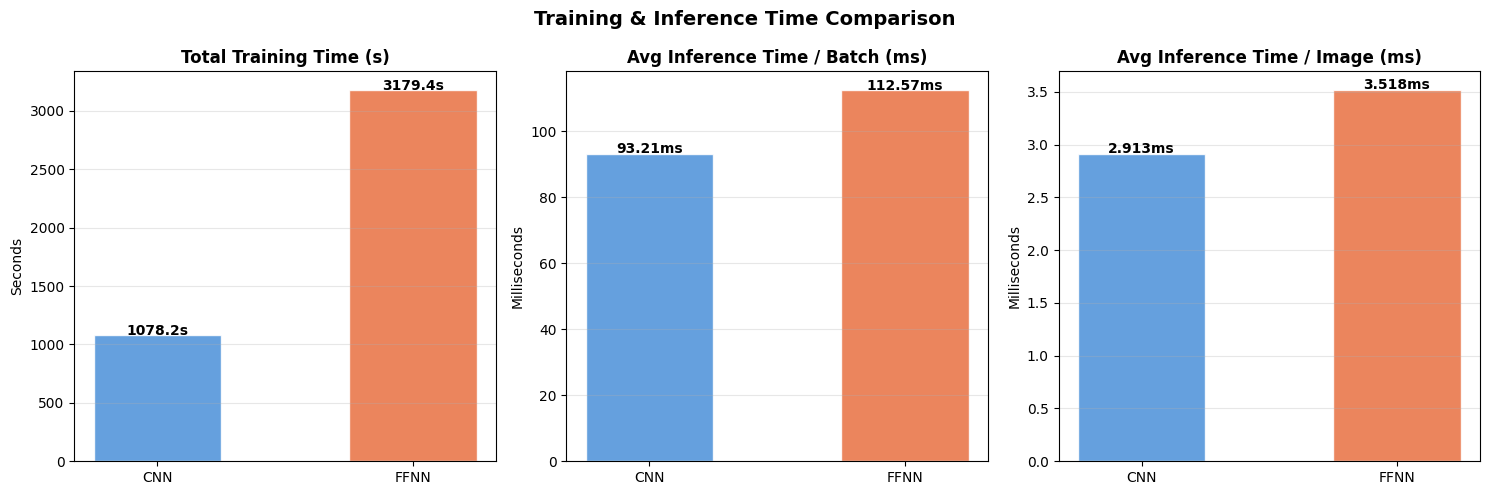


── Timing Summary ──────────────────────────────────
CNN  — Train: 1078.2s | Batch inf: 93.21ms | Per img: 2.913ms
FFNN — Train: 3179.4s | Batch inf: 112.57ms | Per img: 3.518ms


In [8]:
# ── Inference time: measure how long each model takes per batch ──────────────

# FFNN inference timing (PyTorch)
ffnn_model.eval()
ffnn_inf_times = []

with torch.no_grad():
    for images, _ in test_loader:
        images = images.to(DEVICE)
        t0 = time.perf_counter()
        _ = ffnn_model(images)
        ffnn_inf_times.append(time.perf_counter() - t0)

ffnn_avg_inf = np.mean(ffnn_inf_times) * 1000   # convert to ms
ffnn_per_img = ffnn_avg_inf / BATCH_SIZE

# CNN inference timing (Keras)
cnn_inf_times = []
X_test, y_test = loader_to_numpy(test_loader)

for i in range(0, len(X_test), BATCH_SIZE):
    batch = X_test[i:i+BATCH_SIZE]
    t0 = time.perf_counter()
    _ = cnn_model.predict(batch, verbose=0)
    cnn_inf_times.append(time.perf_counter() - t0)

cnn_avg_inf = np.mean(cnn_inf_times) * 1000
cnn_per_img = cnn_avg_inf / BATCH_SIZE

# ── Plot everything together ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Training & Inference Time Comparison', fontsize=14, fontweight='bold')

# Total training time
axes[0].bar(['CNN', 'FFNN'],
            [cnn_train_time, ffnn_history['train_time_sec']],
            color=['#4A90D9', '#E87040'], alpha=0.85, edgecolor='white', width=0.5)
axes[0].set_title('Total Training Time (s)', fontweight='bold')
axes[0].set_ylabel('Seconds')
for i, v in enumerate([cnn_train_time, ffnn_history['train_time_sec']]):
    axes[0].text(i, v + 1, f'{v:.1f}s', ha='center', fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Average inference time per batch
axes[1].bar(['CNN', 'FFNN'],
            [cnn_avg_inf, ffnn_avg_inf],
            color=['#4A90D9', '#E87040'], alpha=0.85, edgecolor='white', width=0.5)
axes[1].set_title('Avg Inference Time / Batch (ms)', fontweight='bold')
axes[1].set_ylabel('Milliseconds')
for i, v in enumerate([cnn_avg_inf, ffnn_avg_inf]):
    axes[1].text(i, v + 0.1, f'{v:.2f}ms', ha='center', fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

# Per-image inference time
axes[2].bar(['CNN', 'FFNN'],
            [cnn_per_img, ffnn_per_img],
            color=['#4A90D9', '#E87040'], alpha=0.85, edgecolor='white', width=0.5)
axes[2].set_title('Avg Inference Time / Image (ms)', fontweight='bold')
axes[2].set_ylabel('Milliseconds')
for i, v in enumerate([cnn_per_img, ffnn_per_img]):
    axes[2].text(i, v + 0.01, f'{v:.3f}ms', ha='center', fontweight='bold')
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('time_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n── Timing Summary ──────────────────────────────────")
print(f"CNN  — Train: {cnn_train_time:.1f}s | Batch inf: {cnn_avg_inf:.2f}ms | Per img: {cnn_per_img:.3f}ms")
print(f"FFNN — Train: {ffnn_history['train_time_sec']:.1f}s | Batch inf: {ffnn_avg_inf:.2f}ms | Per img: {ffnn_per_img:.3f}ms")

## 8 — Regularization Effects Study
We train three variants of the FFNN to isolate the contribution of each regularization technique:
1. **No regularization** — neither Dropout nor BatchNorm
2. **Dropout only** — no BatchNorm
3. **Full regularization** — Dropout + BatchNorm (original model)

In [9]:
REG_EPOCHS = 8   # fewer epochs — we care about the trend, not final accuracy

variants = {
    'No Regularization':   FFNN_COVID(NUM_CLASSES, use_dropout=False, use_batchnorm=False),
    'Dropout Only':        FFNN_COVID(NUM_CLASSES, use_dropout=True,  use_batchnorm=False),
    'Dropout + BatchNorm': FFNN_COVID(NUM_CLASSES, use_dropout=True,  use_batchnorm=True),
}

reg_histories = {}

for name, model in variants.items():
    print(f"\nTraining variant: {name}")
    print('─' * 50)
    _, history = train_ffnn_with_history(
        model, train_loader, val_loader, epochs=REG_EPOCHS
    )
    reg_histories[name] = history


Training variant: No Regularization
──────────────────────────────────────────────────
Epoch [01/8]  Train Loss: 0.8766 Acc: 62.45%  |  Val Loss: 0.7311 Acc: 69.00%
Epoch [02/8]  Train Loss: 0.6968 Acc: 71.46%  |  Val Loss: 0.6608 Acc: 73.01%
Epoch [03/8]  Train Loss: 0.6287 Acc: 74.26%  |  Val Loss: 0.5882 Acc: 76.04%
Epoch [04/8]  Train Loss: 0.5797 Acc: 76.48%  |  Val Loss: 0.5678 Acc: 76.80%
Epoch [05/8]  Train Loss: 0.5379 Acc: 78.40%  |  Val Loss: 0.5103 Acc: 79.69%
Epoch [06/8]  Train Loss: 0.5097 Acc: 79.72%  |  Val Loss: 0.5049 Acc: 80.33%
Epoch [07/8]  Train Loss: 0.4891 Acc: 80.29%  |  Val Loss: 0.4954 Acc: 80.49%
Epoch [08/8]  Train Loss: 0.4674 Acc: 81.43%  |  Val Loss: 0.4882 Acc: 80.80%

Total training time: 2480.7s

Training variant: Dropout Only
──────────────────────────────────────────────────
Epoch [01/8]  Train Loss: 1.0462 Acc: 54.14%  |  Val Loss: 0.8769 Acc: 60.86%
Epoch [02/8]  Train Loss: 0.9109 Acc: 61.02%  |  Val Loss: 0.7976 Acc: 66.19%
Epoch [03/8]  Train

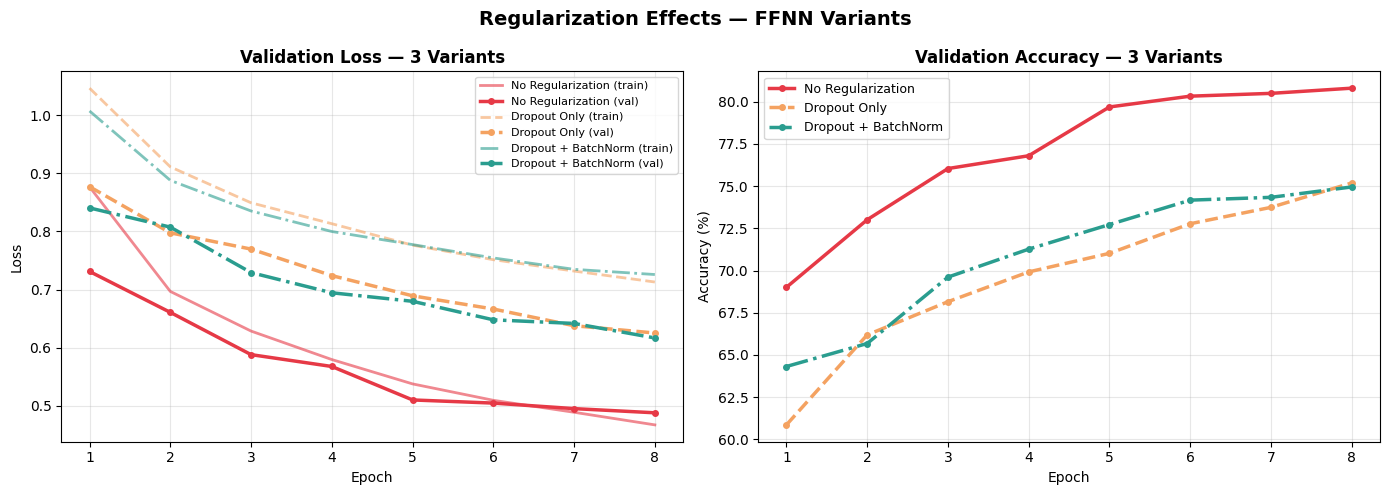

Saved: regularization_effects.png


In [10]:
# ── Plot regularization comparison ───────────────────────────────────────────
reg_epochs_range = range(1, REG_EPOCHS + 1)

VARIANT_COLORS = {
    'No Regularization':   '#E63946',
    'Dropout Only':        '#F4A261',
    'Dropout + BatchNorm': '#2A9D8F',
}

VARIANT_LINES = {
    'No Regularization':   '-',
    'Dropout Only':        '--',
    'Dropout + BatchNorm': '-.',
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Regularization Effects — FFNN Variants', fontsize=14, fontweight='bold')

for name, hist in reg_histories.items():
    c  = VARIANT_COLORS[name]
    ls = VARIANT_LINES[name]

    # Loss plot — train (solid) and val (dashed of same color)
    axes[0].plot(reg_epochs_range, hist['train_loss'],
                 color=c, lw=2, linestyle=ls, alpha=0.6, label=f'{name} (train)')
    axes[0].plot(reg_epochs_range, hist['val_loss'],
                 color=c, lw=2.5, linestyle=ls, marker='o', markersize=4,
                 label=f'{name} (val)')

    # Accuracy plot
    axes[1].plot(reg_epochs_range, [a*100 for a in hist['val_acc']],
                 color=c, lw=2.5, linestyle=ls, marker='o', markersize=4,
                 label=name)

axes[0].set_title('Validation Loss — 3 Variants', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)
axes[0].set_xticks(list(reg_epochs_range))

axes[1].set_title('Validation Accuracy — 3 Variants', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)
axes[1].set_xticks(list(reg_epochs_range))

plt.tight_layout()
plt.savefig('regularization_effects.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: regularization_effects.png")

## 9 — Regularization Summary Table

In [11]:
# Build a clean comparison table for the three FFNN variants
rows = []
for name, hist in reg_histories.items():
    final_train_loss = hist['train_loss'][-1]
    final_val_loss   = hist['val_loss'][-1]
    final_val_acc    = hist['val_acc'][-1] * 100
    # Overfit gap = val_loss - train_loss; positive means overfitting
    overfit_gap      = final_val_loss - final_train_loss
    rows.append({
        'Variant':         name,
        'Train Loss':      round(final_train_loss, 4),
        'Val Loss':        round(final_val_loss,   4),
        'Val Accuracy (%)':round(final_val_acc,    2),
        'Overfit Gap':     round(overfit_gap,       4),
    })

reg_df = pd.DataFrame(rows).set_index('Variant')

styled = (
    reg_df.style
    .highlight_min(subset=['Val Loss', 'Overfit Gap'], color='#d4edda')   # green = better
    .highlight_max(subset=['Val Accuracy (%)'],         color='#d4edda')
    .format({
        'Train Loss': '{:.4f}',
        'Val Loss':   '{:.4f}',
        'Val Accuracy (%)': '{:.2f}%',
        'Overfit Gap': '{:+.4f}'
    })
    .set_caption('Regularization Variants — Final Epoch (green = best)')
)
display(styled)

print("\nNote: A smaller (or negative) Overfit Gap means less overfitting.")
print("Dropout + BatchNorm should show the best balance between train and val.")

,Train Loss,Val Loss,Val Accuracy (%),Overfit Gap
Variant,,,,
No Regularization,0.4674,0.4882,80.80%,+0.0208
Dropout Only,0.7130,0.6254,75.19%,-0.0877
Dropout + BatchNorm,0.7259,0.6168,74.95%,-0.1090



Note: A smaller (or negative) Overfit Gap means less overfitting.
Dropout + BatchNorm should show the best balance between train and val.


## 10 — Full Summary Dashboard

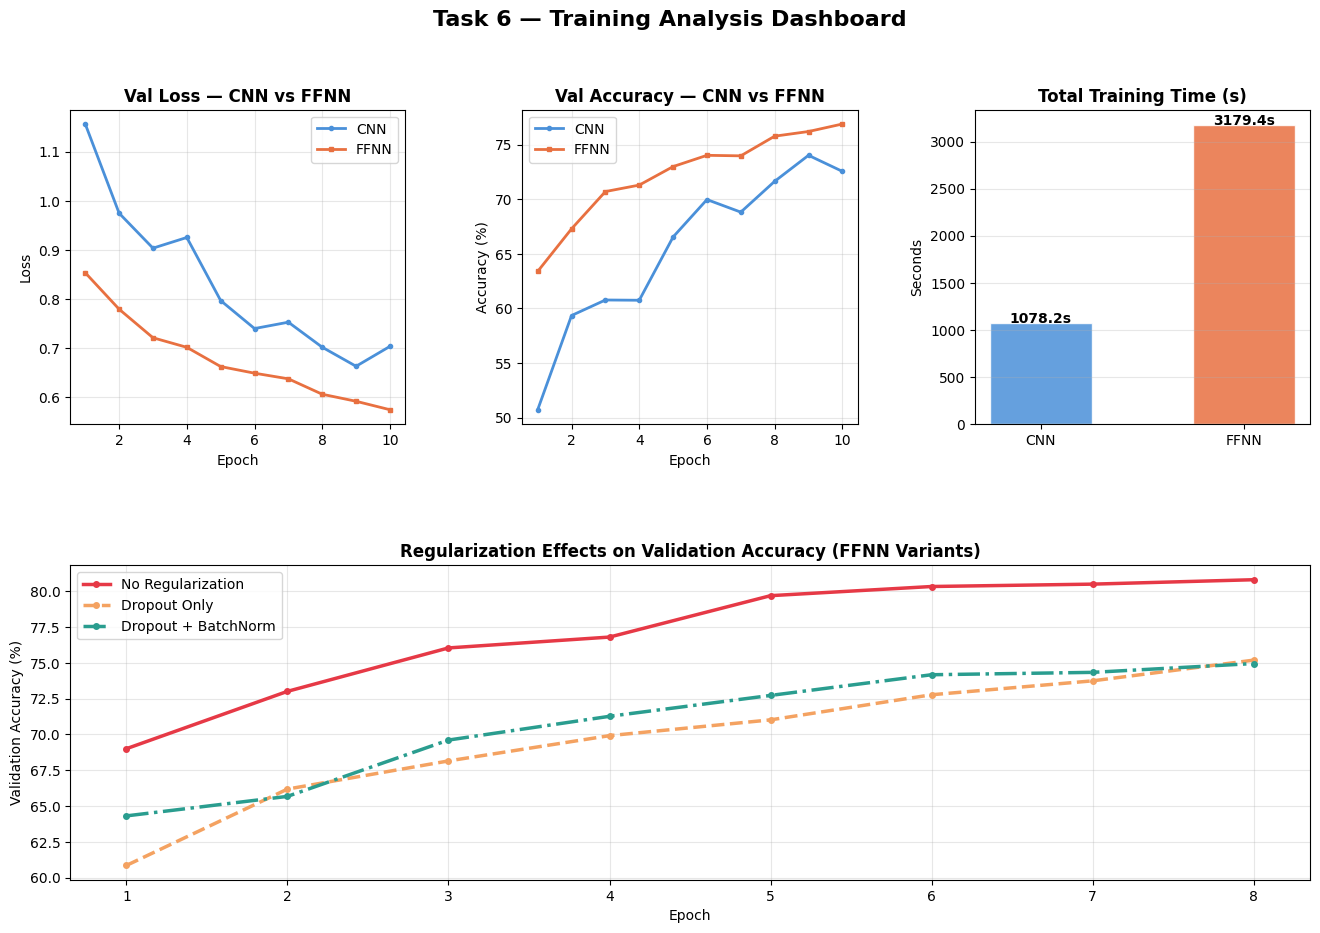

Saved: task6_dashboard.png


In [12]:
fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)
fig.suptitle('Task 6 — Training Analysis Dashboard', fontsize=16, fontweight='bold')

# ── Top row: CNN vs FFNN validation loss and accuracy ───────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(epochs_range, cnn_history['val_loss'],  lw=2, color='#4A90D9',
         marker='o', markersize=3, label='CNN')
ax1.plot(epochs_range, ffnn_history['val_loss'], lw=2, color='#E87040',
         marker='s', markersize=3, label='FFNN')
ax1.set_title('Val Loss — CNN vs FFNN', fontweight='bold')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.legend(); ax1.grid(alpha=0.3)

ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(epochs_range, [v*100 for v in cnn_history['val_acc']],  lw=2,
         color='#4A90D9', marker='o', markersize=3, label='CNN')
ax2.plot(epochs_range, [v*100 for v in ffnn_history['val_acc']], lw=2,
         color='#E87040', marker='s', markersize=3, label='FFNN')
ax2.set_title('Val Accuracy — CNN vs FFNN', fontweight='bold')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)')
ax2.legend(); ax2.grid(alpha=0.3)

# ── Top right: training time bar ────────────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
ax3.bar(['CNN', 'FFNN'],
        [cnn_train_time, ffnn_history['train_time_sec']],
        color=['#4A90D9', '#E87040'], alpha=0.85, edgecolor='white', width=0.5)
ax3.set_title('Total Training Time (s)', fontweight='bold')
ax3.set_ylabel('Seconds'); ax3.grid(axis='y', alpha=0.3)
for i, v in enumerate([cnn_train_time, ffnn_history['train_time_sec']]):
    ax3.text(i, v + 0.5, f'{v:.1f}s', ha='center', fontweight='bold')

# ── Bottom row: regularization val accuracy ──────────────────────────────────
ax4 = fig.add_subplot(gs[1, :])
for name, hist in reg_histories.items():
    ax4.plot(reg_epochs_range, [v*100 for v in hist['val_acc']],
             color=VARIANT_COLORS[name], lw=2.5,
             linestyle=VARIANT_LINES[name], marker='o', markersize=4, label=name)
ax4.set_title('Regularization Effects on Validation Accuracy (FFNN Variants)',
              fontweight='bold')
ax4.set_xlabel('Epoch'); ax4.set_ylabel('Validation Accuracy (%)')
ax4.legend(fontsize=10); ax4.grid(alpha=0.3)
ax4.set_xticks(list(reg_epochs_range))

plt.savefig('task6_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: task6_dashboard.png")